# Diagnóstico de Modelos: Curvas de Aprendizaje y Validación
 **¿Cuántos Datos Necesito? ¿Más es mejor?**


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/90_casos_estudio/cuantos_datos_necesito.ipynb)



## Objetivos del Caso de Estudio


- **Perspectiva de Negocio:** Responder matemáticamente al dilema del Director de Datos (CDO): *"¿Invertimos presupuesto en recolectar más datos o invertimos horas de ingeniería en ajustar el modelo actual?"*
- **Perspectiva de Ingeniería:** Diagnosticar el estado de un modelo en producción evaluando el *Trade-off* Sesgo-Varianza mediante **Curvas de Aprendizaje** (`learning_curve`).
- **Optimización sin Datos:** Implementar **Curvas de Validación** (`validation_curve`) para demostrar cómo solucionar problemas de sobreajuste (*Overfitting*) ajustando la complejidad del modelo sin gastar dinero en datos nuevos.



## Prerrequisitos


- Entendimiento del *Trade-off* Sesgo-Varianza y Validación Cruzada.
- Haber completado el Capítulo 3 (*Machine Learning*), especialmente: [Optimización de Hiperparámetros y Validación Cruzada](../03_machine_learning/07_optimizacion_hiperparametros_y_cv.ipynb).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

## 1. Introducción: El Dilema del Presupuesto


En el mundo ideal del Machine Learning, tendríamos cantidades infinitas de datos perfectamente etiquetados. En la realidad, obtener datos tiene un costo masivo (tiempo, almacenamiento, anotación humana).

Cuando un modelo en producción no alcanza el rendimiento deseado (ej. se estanca en un 85% de *Accuracy*), los equipos junior suelen reaccionar pidiendo "más datos". Sin embargo, **si el modelo sufre de Alto Sesgo (es demasiado simple), podemos darle mil millones de datos y su rendimiento no mejorará ni un 1%**.

Para no tirar el presupuesto a la basura, los ingenieros utilizan herramientas de diagnóstico, de modo de determinar la raíz del problema.

Para recordar estos conceptos, estos son los posibles casos combinados:

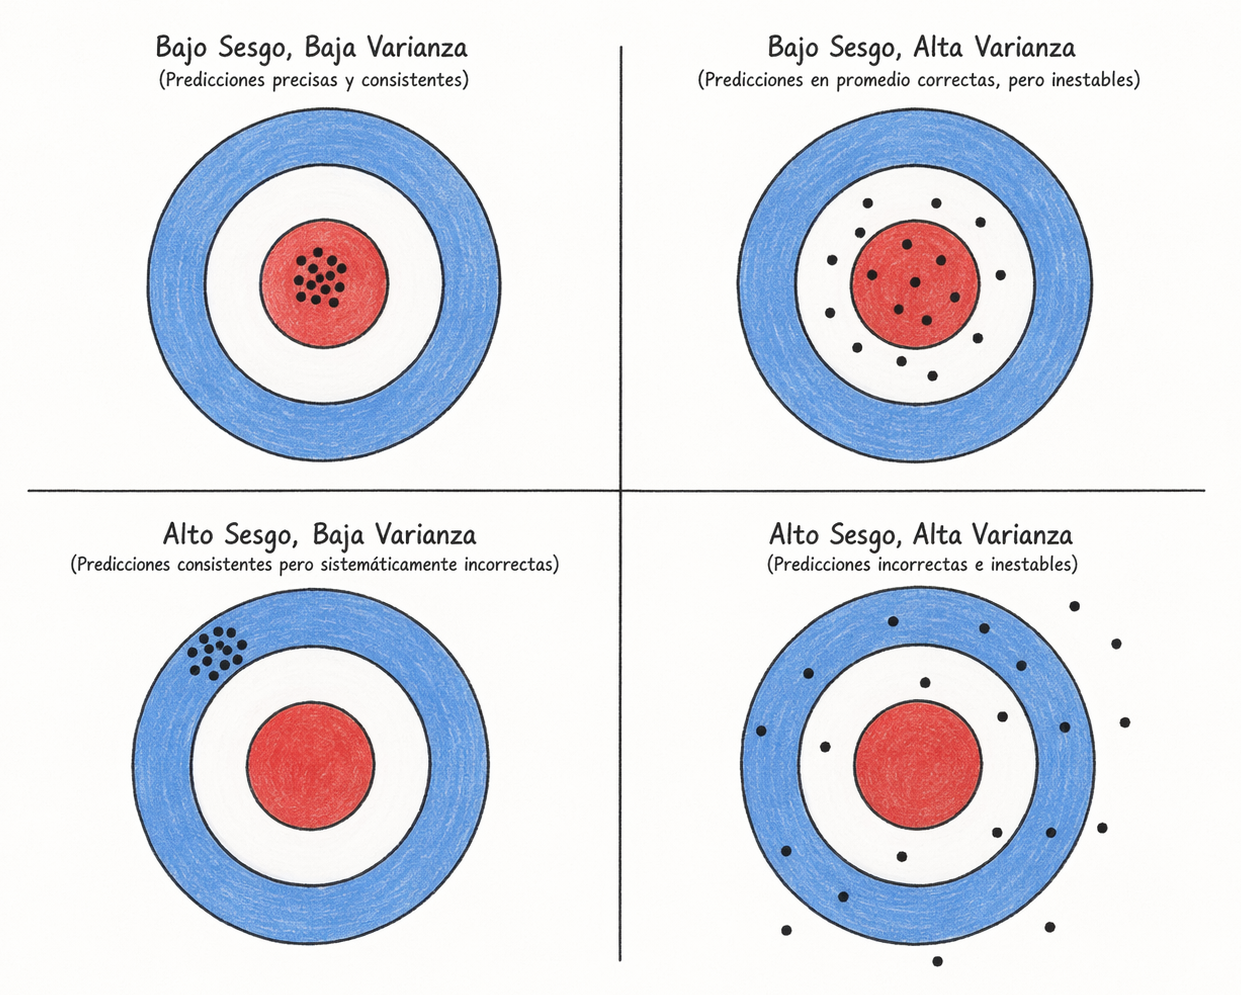

## 2. El Caso de Negocio: OCR para Cheques Bancarios



Trabajamos en un banco que está automatizando el cobro de cheques mediante una aplicación móvil. Necesitamos un modelo de Reconocimiento Óptico de Caracteres (OCR) para leer los números escritos a mano.

Utilizamos el dataset `digits` (imágenes de 8x8 píxeles). Tenemos `~1.800` imágenes etiquetadas. El equipo de producto pregunta: *"¿Necesitamos pedirle a los usuarios que suban 10.000 fotos más para mejorar el sistema?"*

Vamos a tratar de diagnosticar esto y responder la pregunta...

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve, validation_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. Carga de datos
digits = load_digits()
X, y = digits.data, digits.target

print(f"Imágenes disponibles: {X.shape[0]}")
print(f"Píxeles por imagen (Features): {X.shape[1]}")

# 2. Definimos dos arquitecturas opuestas para el diagnóstico
# Arquitectura A: Modelo Lineal "Lisiado" (Fuerte regularización C=0.001 para forzar Alto Sesgo)
pipeline_lineal = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.001, max_iter=1000, random_state=42))
])

# Arquitectura B: Modelo No Lineal Sobreajustado (Gamma=0.1 fuerza la Alta Varianza)
pipeline_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', gamma=0.1, random_state=42))
])

Imágenes disponibles: 1797
Píxeles por imagen (Features): 64


## 3. Curvas de Aprendizaje (El Valor de los Datos)



La función `learning_curve` de Scikit-Learn entrena el modelo repetidas veces, dándole cada vez un subconjunto más grande de los datos (ej. 10%, 20%... 100%). En cada paso, mide el error en el entrenamiento y el error en la validación cruzada.



Calculando Curvas de Aprendizaje (Esto tomará unos segundos)...


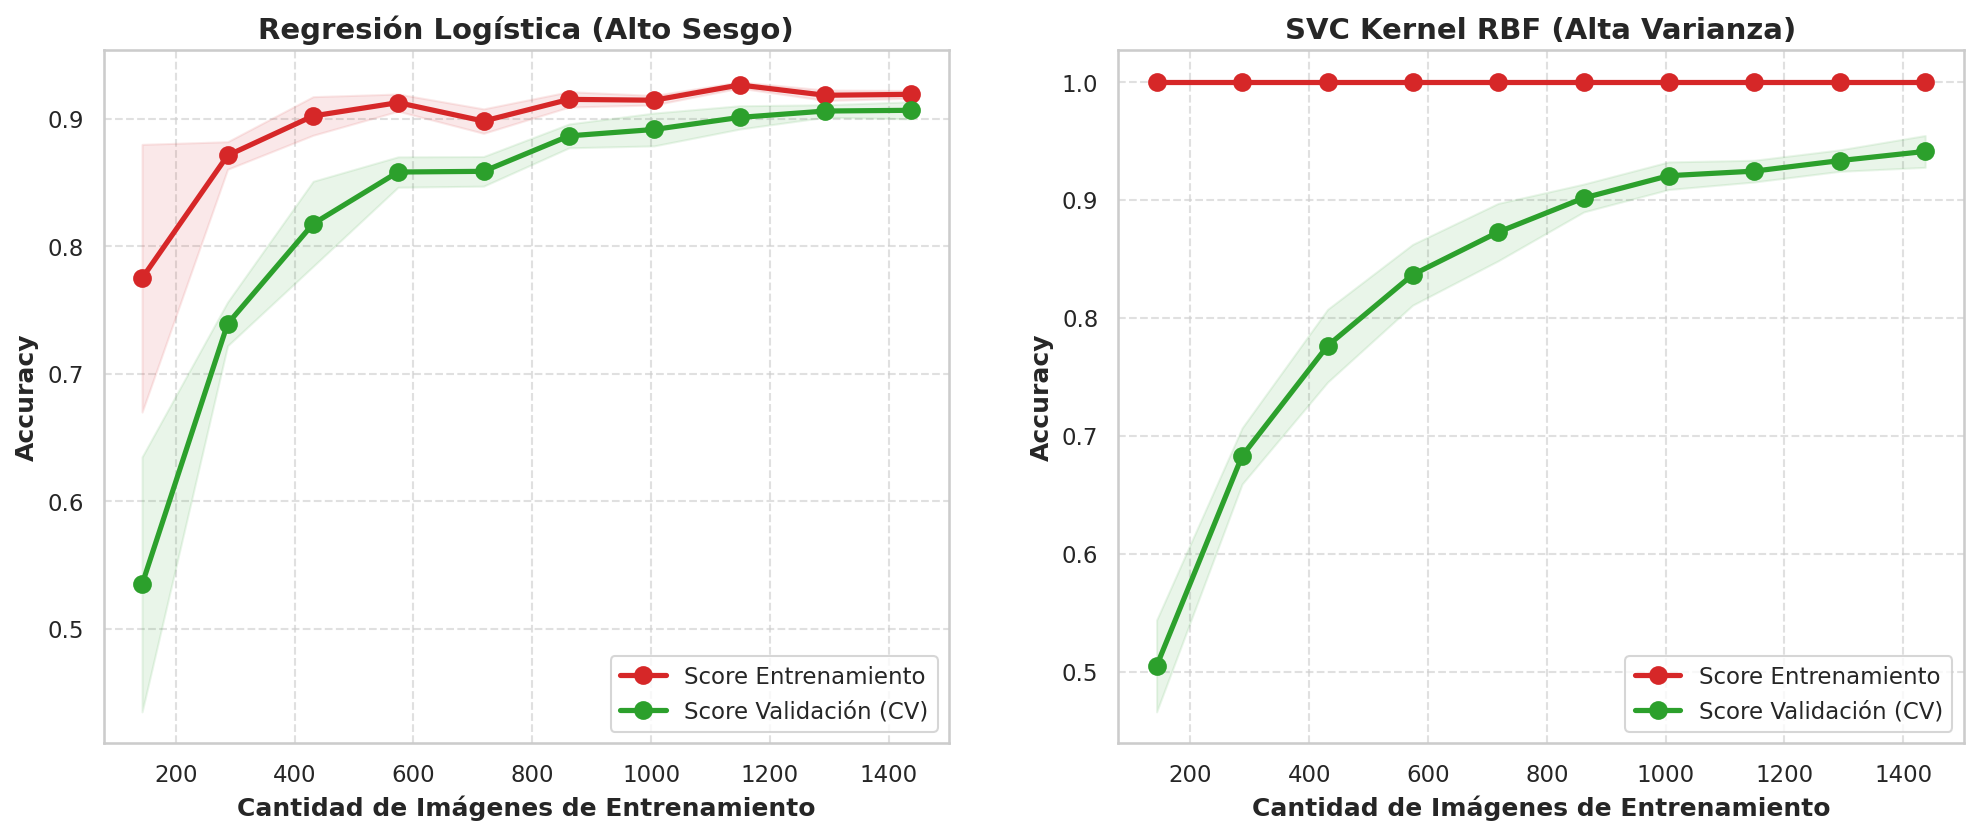

In [19]:
# Función para graficar curvas
def plot_diagnostico(train_sizes, train_scores, test_scores, title, xlabel, ax):
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Score Entrenamiento")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")

    ax.plot(train_sizes, test_mean, 'o-', color="#2ca02c", label="Score Validación (CV)")
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Accuracy")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc="best")

# Estrategia de Validación Cruzada robusta
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tamanos_entrenamiento = np.linspace(0.1, 1.0, 10) # Del 10% al 100% de los datos

# Generamos las curvas para ambos modelos
print("Calculando Curvas de Aprendizaje (Esto tomará unos segundos)...")
train_sizes_lin, train_scores_lin, test_scores_lin = learning_curve(
    pipeline_lineal, X, y, cv=cv_strategy, n_jobs=-1, train_sizes=tamanos_entrenamiento)

train_sizes_rbf, train_scores_rbf, test_scores_rbf = learning_curve(
    pipeline_rbf, X, y, cv=cv_strategy, n_jobs=-1, train_sizes=tamanos_entrenamiento)

# Visualizamos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_diagnostico(train_sizes_lin, train_scores_lin, test_scores_lin,
                 "Regresión Logística (Alto Sesgo)", "Cantidad de Imágenes de Entrenamiento", axes[0])
plot_diagnostico(train_sizes_rbf, train_scores_rbf, test_scores_rbf,
                 "SVC Kernel RBF (Alta Varianza)", "Cantidad de Imágenes de Entrenamiento", axes[1])
plt.show()

### Análisis del Gráfico



1. **Regresión Logística (Izquierda - Underfitting):**
   - **Síntoma:** Las curvas roja y verde se "aplastan" rápidamente y convergen. La brecha (*gap*) entre ellas es casi nula. Sin embargo, el *Accuracy* se estanca alrededor del **90-91%**.
   - **Diagnóstico:** El modelo tiene un Alto Sesgo. Aunque un 91% suena bien en otros contextos, para este problema de reconocimiento de dígitos (donde es fácil llegar al 99%), es un claro subajuste. Al tener una regularización tan fuerte, el modelo carece de la capacidad matemática para entender los detalles finos de la caligrafía.
   - **Decisión de Negocio:** **NO COMPRAR MÁS DATOS.** La curva ya es plana. Añadir 10.000 imágenes más no subirá ese 91%. Se debe cambiar a un modelo más complejo o relajar la regularización.

2. **SVC Kernel RBF (Derecha - Overfitting):**
   - **Síntoma:** La curva roja (Entrenamiento) está clavada en el 100% (memorización perfecta). La curva verde (Validación) va subiendo pero **se mantiene por debajo (~94%)**. Hay una **brecha clara** entre ambas que no termina de cerrarse.
   - **Diagnóstico:** El modelo tiene Alta Varianza. Es demasiado complejo y está memorizando el ruido exacto de los píxeles de entrenamiento, lo que le impide generalizar perfectamente a imágenes nuevas.
   - **Decisión de Negocio:** **SÍ, MÁS DATOS AYUDARÍAN.** Observar cómo la curva verde sigue teniendo una pendiente ascendente al final del gráfico. Si le damos 5.000 imágenes más, la curva verde eventualmente alcanzará a la roja. Sin embargo, la forma más barata de cerrar esta brecha hoy mismo es ajustando la complejidad del modelo.


## 4. Curvas de Validación (El Valor del Ajuste de Hiperparámetros)



Supongamos que el Director de Datos nos dice: *"Entendido, el SVC necesita más datos. Pero no tenemos presupuesto para recolectar más imágenes este trimestre. ¿Qué hacemos?"*

Aquí es donde entra la **Curva de Validación**. Si no podemos darle más datos al modelo para reducir la varianza, debemos **reducir la complejidad del modelo** ajustando sus hiperparámetros.

En el SVC, el hiperparámetro `gamma` controla la flexibilidad de la frontera de decisión. Un `gamma` alto crea "islas" alrededor de cada punto (Alta Varianza). Un `gamma` bajo crea fronteras suaves.

Vamos a mantener la cantidad de datos fija (usamos el 100% del dataset) y variamos el valor de `gamma`.

Calculando Curvas de Validación...


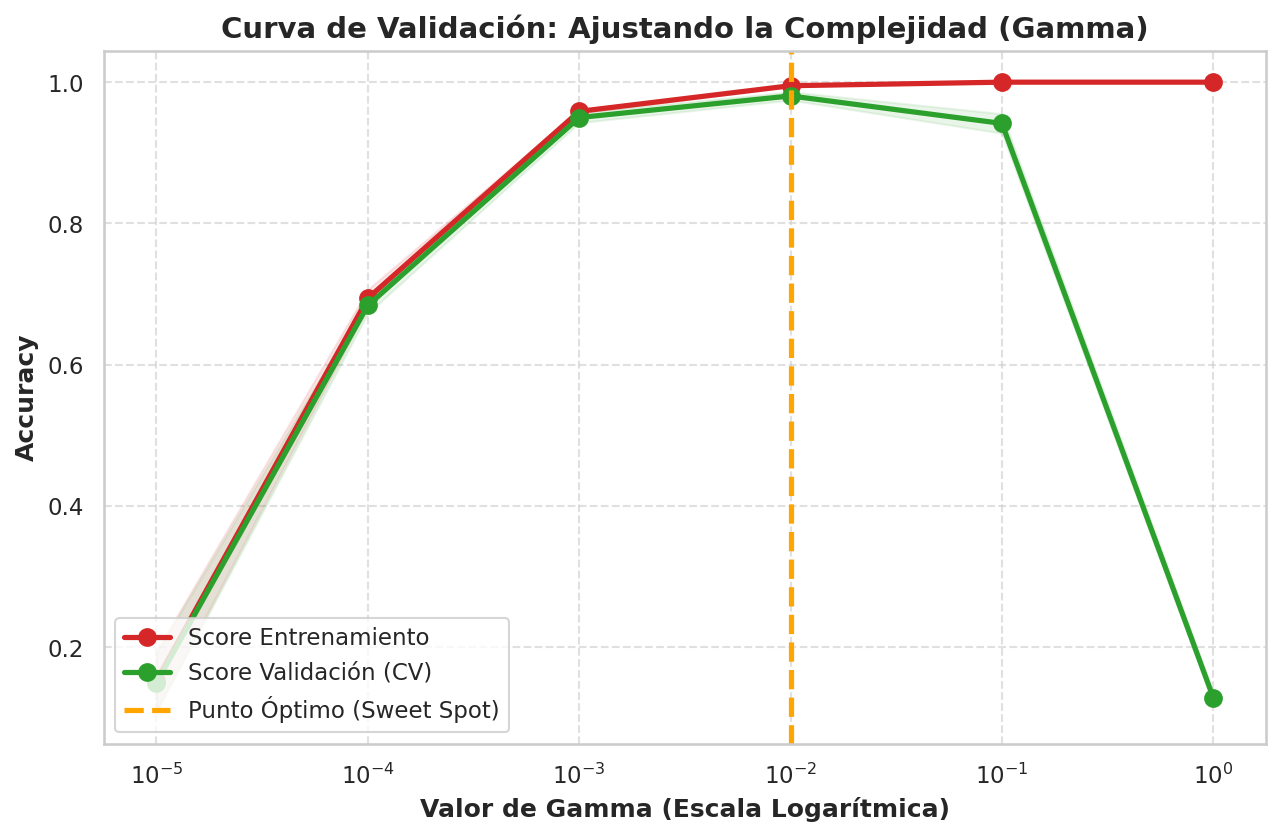

In [20]:
# Definimos el rango del hiperparámetro a explorar (escala logarítmica es ideal para gamma)
param_range = np.logspace(-5, 0, 6) # Valores desde 0.00001 hasta 1.0

print("Calculando Curvas de Validación...")
train_scores_val, test_scores_val = validation_curve(
    pipeline_rbf, X, y,
    param_name="clf__gamma",
    param_range=param_range,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

# Visualizamos
fig, ax = plt.subplots(figsize=(10, 6))
plot_diagnostico(param_range, train_scores_val, test_scores_val,
                 "Curva de Validación: Ajustando la Complejidad (Gamma)", "Valor de Gamma (Escala Logarítmica)", ax)
ax.set_xscale('log')

# Marcamos la zona óptima
plt.axvline(x=0.01, color='orange', linestyle='--', label='Punto Óptimo (Sweet Spot)')
plt.legend(loc='lower left')
plt.show()

### Análisis: La Solución de Ingeniería


Observar el eje X (de izquierda a derecha, la complejidad del modelo aumenta):
1. **Extremo Izquierdo (`gamma = 10^-5`):** Ambas curvas **se desploman hacia el 15-20%**. El modelo se vuelve tan rígido y plano que es incapaz de aprender absolutamente nada (Alto Sesgo Extremo).
2. **Extremo Derecho (`gamma = 10^0`):** La curva roja sigue en 100%, pero **la curva verde colapsa hacia el 10%** (equivalente a adivinar al azar en este problema). El modelo ha memorizado tanto los datos de entrenamiento que es inútil en el mundo real (Alta Varianza Extrema).
3. **El Centro (`gamma = 10^-2`):** ¡El *Sweet Spot*! Ambas curvas están en su punto más alto (~98-99% de *Accuracy*) y la brecha entre ellas es mínima.

**Conclusión de Negocio:**
Al realizar este diagnóstico, solucionamos el problema de rendimiento del sistema de OCR **sin gastar nada en recolectar nuevos datos**. Los existentes, eran suficientes para modelar el problema. Simplemente ajustamos la perilla de complejidad matemática (`gamma`) para que coincida con la cantidad de datos que ya teníamos.

## 5. Matriz de Decisión (*Cheat Sheet*)


Tabla mental que resume todo:

| Diagnóstico Visual (Curvas) | Problema Subyacente | Solución Estratégica (Qué hacer) |
| :--- | :--- | :--- |
| **Curvas bajas, juntas y planas** | **Alto Sesgo** (Underfitting) | NO buscar más datos.<br>Usar un modelo más complejo (ej. Árboles en lugar de Lineal).<br>Crear nuevas variables (Feature Engineering).<br>Reducir la regularización. |
| **Curva Train alta, Curva Val baja (Gran Brecha)** | **Alta Varianza** (Overfitting) | SÍ, recolectar más datos (Usar *Active Learning*).<br>Simplificar el modelo (Podar el árbol, bajar el `gamma`).<br>Aumentar la regularización (L1/L2).<br>Eliminar variables ruidosas (Feature Selection). |
| **Curvas altas, juntas y planas** | **Modelo Óptimo** | Listo para producción. El modelo ha extraído todo el valor posible de los datos actuales. |

## Conclusión


Las Curvas de Aprendizaje y Validación son el equivalente a la radiografía y el análisis de sangre en la medicina. Antes de recetar un tratamiento costoso (comprar datos o alquilar GPUs para entrenar Redes Neuronales), un ingeniero profesional siempre diagnostica el estado actual del sistema y toma decisiones informadas.

**NOTA**: Pensando en el otro extremo, es decir, tenemos millones de datos (sobran)... un análisis como este permite determinar un muestreo representativo y suficiente para llevar adelante pruebas. Evitando los altos costes vinculados a procesar las millones de muestras en cada experimento. Es decir, podría encontrar la respuesta a ¿cuántas muestras necesito realmente para alcanzar el máximo desempeño en este problema?, y trabajar con un corpus acotado.

## Referencias


1. Ng, A. Y. (2018). *Machine learning yearning*. Draft Version. (Capítulos sobre Bias y Variance).
2. [Scikit-Learn: Validation curves: plotting scores to evaluate models](https://scikit-learn.org/stable/modules/learning_curve.html)

---


## Entorno de Ejecución


In [21]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
